## **Task 1: Notebook Structure & Data Loading**

In [22]:
# Importing Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class HealthcareOperationsAnalysis:
    def __init__(self):
        self.df = None

    # Task 1: Notebook Structure & Data Loading
    def load_data(self):
        file_path = input("Enter Path of file: ")
        self.df = pd.read_csv(file_path)
        print("Dataset Loaded Successfully")
        self.df["Admission_Date"] = pd.to_datetime(self.df["Admission_Date"], errors="coerce")
    def dataset_shape(self):
        print(self.df.shape)

    def first_5_rows(self):
        print(self.df.head())

    def last_5_rows(self):
        print(self.df.tail())

    # Task 2: Data Cleaning & EDA
    def check_and_fill_nulls(self):
        print(self.df.isnull().sum())
    
        # Fill missing values
        self.df["Department"] = self.df["Department"].fillna("General")
        self.df["Hospital_Region"] = self.df["Hospital_Region"].fillna("Unknown")
        self.df["City"] = self.df["City"].fillna("Unknown")
        self.df["Patient_Type"] = self.df["Patient_Type"].fillna("Unknown")
        self.df["Insurance_Type"] = self.df["Insurance_Type"].fillna("Unknown")
        self.df["Discharge_Status"] = self.df["Discharge_Status"].fillna("Unknown")
        self.df["Treatment_Cost"] = self.df["Treatment_Cost"].fillna(self.df["Treatment_Cost"].median())
        self.df["Length_of_Stay_Days"] = self.df["Length_of_Stay_Days"].fillna(self.df["Length_of_Stay_Days"].median())
    
        print("Null values Filled")
        print(self.df.isnull().sum())


    def check_duplicates_and_remove(self):
        print("Duplicates:", self.df.duplicated().sum())
        self.df = self.df.drop_duplicates()
        print("New Shape after removing duplicates:", self.df.shape)

    def statistical_summary(self):
        print(self.df.describe())

    def department_distribution(self):
        print(self.df["Department"].value_counts())

    def region_distribution(self):
        print(self.df["Hospital_Region"].value_counts())

    # Task 3: Healthcare / Operational Data Analysis
    def dept_patient_volume(self):
        dept_count = self.df["Department"].value_counts()
        print(dept_count)

    def avg_treatment_cost_per_department(self):
        avg_treatment_cost = self.df.groupby("Department")["Treatment_Cost"].mean().sort_values()
        print(avg_treatment_cost)

    def region_wise_hospital_load(self):
        region = self.df["Hospital_Region"].value_counts()
        print(region)

    def patient_type_vs_length_of_stay(self):
        patient_length_of_stay = self.df.groupby("Patient_Type")["Length_of_Stay_Days"].mean()
        print(patient_length_of_stay)

    def insurance_type_vs_treatment_cost(self):
        insurance_cost = self.df.groupby("Insurance_Type")["Treatment_Cost"].mean().sort_values()
        print(insurance_cost)

    # Task 4: Data Visualization
    def bar_chart_department_patient_count(self):
        sns.countplot(data=self.df, x="Department",
                      order=self.df["Department"].value_counts().index, color="blue")
        plt.title("Department vs Patient Count")
        plt.xlabel("Department")
        plt.ylabel("Patient Count")
        plt.grid(axis="y", linestyle="--", alpha=0.6, color="red")
        plt.show()
        print("Departments with higher patient count may face operational overload and longer wait times.")

    def line_chart_monthly_admission_trend(self):
        monthly = self.df.groupby(self.df["Admission_Date"].dt.month).size()
        plt.plot(monthly.index, monthly.values, marker="o", color="green")
        plt.title("Monthly Admission Trend")
        plt.xlabel("Month")
        plt.ylabel("Admissions")
        plt.grid(axis="y", linestyle="--", alpha=0.6)
        plt.show()
        print("First 6 months have more admissions than the last 6 months of a year so hospitals need better planning for peak months")

    def histogram_treatment_cost_distribution(self):
        sns.histplot(self.df["Treatment_Cost"], bins=50, kde=True, color="orange")
        plt.title("Treatment Cost Distribution")
        plt.xlabel("Treatment Cost")
        plt.ylabel("Number of Patients")
        plt.show()
        print("Most patients fall in a certain cost range while few patients have very high treatment cost.")

    def pie_chart_patient_type_distribution(self):
        pt = self.df["Patient_Type"].value_counts()
        colors = ["pink", "skyblue", "yellow"]
        plt.pie(pt, labels=pt.index, autopct="%1.1f%%", colors=colors, shadow=5)
        plt.title("Patient Type Distribution")
        plt.show()
        print("Shows the ratio between types of patients")

    def scatter_plot_treatment_cost_vs_stay(self):
        sns.scatterplot(data=self.df, y="Treatment_Cost", x="Length_of_Stay_Days", color="Red")
        plt.title("Treatment Cost vs Length of stay")
        plt.ylabel("Treatment Cost")
        plt.xlabel("Length of stay days")
        plt.show()
        print("Shows the cost of treatment based on days the patient stayed")

    def subplots_region_and_insurance(self):
        plt.figure(figsize=(14, 6))

        plt.subplot(1, 2, 1)
        region_counts = self.df["Hospital_Region"].value_counts()
        plt.bar(region_counts.index, region_counts.values, color="Pink", edgecolor="black")
        plt.title("Region-wise Hospital Load")
        plt.xlabel("Hospital Region")
        plt.ylabel("Number of Patients")
        plt.grid(axis="y", linestyle="--", alpha=0.6)

        plt.subplot(1, 2, 2)
        insurance_counts = self.df["Insurance_Type"].value_counts()
        plt.bar(insurance_counts.index, insurance_counts.values, color="lightgreen", edgecolor="black")
        plt.title("Insurance Type Distribution")
        plt.xlabel("Insurance Type")
        plt.ylabel("Count")
        plt.grid(axis="y", linestyle="--", alpha=0.6)

        plt.tight_layout()
        plt.show()

        print("Regions with higher patient load need more resources and insurance type distribution shows the common payment methods used in hospitals.")

    # Menu Driven Function
    def graphs_menu(self):
        while True:
            print("\nGraphs Menu")
            print("1. Bar Chart: Department vs Patient Count")
            print("2. Line Chart: Monthly Admission Trend")
            print("3. Histogram: Treatment Cost Distribution")
            print("4. Pie Chart: Patient Type Distribution")
            print("5. Scatter Plot: Treatment Cost vs Length of Stay")
            print("6. Subplots: Region Load and Insurance Distribution")
            print("0. Back to Main Menu")

            g_choice = input("Enter your choice: ")

            if g_choice == "1":
                self.bar_chart_department_patient_count()
            elif g_choice == "2":
                self.line_chart_monthly_admission_trend()
            elif g_choice == "3":
                self.histogram_treatment_cost_distribution()
            elif g_choice == "4":
                self.pie_chart_patient_type_distribution()
            elif g_choice == "5":
                self.scatter_plot_treatment_cost_vs_stay()
            elif g_choice == "6":
                self.subplots_region_and_insurance()
            elif g_choice == "0":
                break
            else:
                print("Invalid choice. Try again.")

    # Menu Driven Function (Main Menu)
    def menu(self):
        while True:
            print("\nMain Menu")
            print("1. Load Dataset")
            print("2. Dataset Shape")
            print("3. First 5 Rows")
            print("4. Last 5 Rows")
            print("5. Check Null Values")
            print("6. Check and Remove Duplicates")
            print("7. Statistical Summary")
            print("8. Department Distribution")
            print("9. Region Distribution")
            print("10. Department-wise Patient Volume")
            print("11. Average Treatment Cost per Department")
            print("12. Region-wise Hospital Load")
            print("13. Patient Type vs Length of Stay")
            print("14. Insurance Type vs Treatment Cost")
            print("15. Graphs Menu")
            print("0. Exit")

            choice = input("Enter your choice: ")

            if choice == "1":
                self.load_data()
            elif choice == "2":
                self.dataset_shape()
            elif choice == "3":
                self.first_5_rows()
            elif choice == "4":
                self.last_5_rows()
            elif choice == "5":
                self.check_and_fill_nulls()
            elif choice == "6":
                self.check_duplicates_and_remove()
            elif choice == "7":
                self.statistical_summary()
            elif choice == "8":
                self.department_distribution()
            elif choice == "9":
                self.region_distribution()
            elif choice == "10":
                self.dept_patient_volume()
            elif choice == "11":
                self.avg_treatment_cost_per_department()
            elif choice == "12":
                self.region_wise_hospital_load()
            elif choice == "13":
                self.patient_type_vs_length_of_stay()
            elif choice == "14":
                self.insurance_type_vs_treatment_cost()
            elif choice == "15":
                self.graphs_menu()
            elif choice == "0":
                break
            else:
                print("Invalid choice. Try again.")


if __name__ == "__main__":
    app = HealthcareOperationsAnalysis()
    app.menu()



Main Menu
1. Load Dataset
2. Dataset Shape
3. First 5 Rows
4. Last 5 Rows
5. Check Null Values
6. Check and Remove Duplicates
7. Statistical Summary
8. Department Distribution
9. Region Distribution
10. Department-wise Patient Volume
11. Average Treatment Cost per Department
12. Region-wise Hospital Load
13. Patient Type vs Length of Stay
14. Insurance Type vs Treatment Cost
15. Graphs Menu
0. Exit


Enter your choice:  1
Enter Path of file:  Healthcare_Hospital_Operations_Gigantic_Dataset - Healthcare_Hospital_Operations_Gigantic_Dataset.csv.csv


Dataset Loaded Successfully

Main Menu
1. Load Dataset
2. Dataset Shape
3. First 5 Rows
4. Last 5 Rows
5. Check Null Values
6. Check and Remove Duplicates
7. Statistical Summary
8. Department Distribution
9. Region Distribution
10. Department-wise Patient Volume
11. Average Treatment Cost per Department
12. Region-wise Hospital Load
13. Patient Type vs Length of Stay
14. Insurance Type vs Treatment Cost
15. Graphs Menu
0. Exit


Enter your choice:  5


Patient_ID                 0
Admission_Date             0
Hospital_Region        17082
City                    7519
Department              6862
Patient_Type            6805
Length_of_Stay_Days     2271
Treatment_Cost             0
Insurance_Type          6692
Discharge_Status        6725
dtype: int64
Null values Filled
Patient_ID                0
Admission_Date            0
Hospital_Region        3000
City                   3000
Department             3000
Patient_Type           3000
Length_of_Stay_Days    3000
Treatment_Cost         3000
Insurance_Type         3000
Discharge_Status       3000
dtype: int64

Main Menu
1. Load Dataset
2. Dataset Shape
3. First 5 Rows
4. Last 5 Rows
5. Check Null Values
6. Check and Remove Duplicates
7. Statistical Summary
8. Department Distribution
9. Region Distribution
10. Department-wise Patient Volume
11. Average Treatment Cost per Department
12. Region-wise Hospital Load
13. Patient Type vs Length of Stay
14. Insurance Type vs Treatment Cost
15. Gr

In [34]:
# Loaading the dataset Healthcare_Hospital_Operations_Gigantic_Dataset.csv

file_path=input("Enter Path of file")
df = pd.read_csv(file_path)
print("Dataset Loaded Successfully")

Enter Path of file Healthcare_Hospital_Operations_Gigantic_Dataset - Healthcare_Hospital_Operations_Gigantic_Dataset.csv.csv


Dataset Loaded Successfully


In [35]:
# Dataset shape, No of rows and colums
df.shape

(68000, 10)

In [36]:
# First 5 rows
df.head()

,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
0,800000,2022-01-21,Central,Mumbai,General,Inpatient,12.0,30716.80,Private,Recovered
1,800001,2023-01-27,South,Mumbai,General,Inpatient,1.0,197617.22,Self-Pay,Referred
2,800002,2023-12-30,NaN,Chennai,Neurology,Inpatient,8.0,403505.37,Private,Recovered
3,800003,2023-08-02,NaN,Chennai,Neurology,Outpatient,22.0,19975.17,Private,Recovered
4,800004,2023-10-21,South,NaN,Pediatrics,NaN,NaN,434580.60,Government,NaN


In [37]:
# Last 5 rows
df.tail()

,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
67995,821041,2024-05-31,Central,Pune,Oncology,Inpatient,21.0,463084.12,Self-Pay,Recovered
67996,844371,2023-11-07,NaN,Delhi,NaN,NaN,14.0,347293.28,Self-Pay,Critical
67997,835040,2023-10-30,NaN,NaN,Cardiology,Inpatient,6.0,367992.20,Self-Pay,Referred
67998,855047,2024-03-02,East,Chennai,Neurology,Inpatient,27.0,20610.72,Self-Pay,Recovered
67999,815102,2022-10-11,Central,Mumbai,NaN,Outpatient,17.0,73405.17,Self-Pay,Recovered


## **Task 2: Data Cleaning & EDA**

In [38]:
# Checks how many null rows are there in dataset

df.isnull().sum()

Patient_ID                 0
Admission_Date             0
Hospital_Region        17082
City                    7519
Department              6862
Patient_Type            6805
Length_of_Stay_Days     2271
Treatment_Cost             0
Insurance_Type          6692
Discharge_Status        6725
dtype: int64

In [41]:
# Use fillna function to fill missing values

df["Department"] = df["Department"].fillna("General")
df["Hospital_Region"] = df["Hospital_Region"].fillna("Unknown")
df["City"] = df["City"].fillna("Unknown")
df["Patient_Type"] = df["Patient_Type"].fillna("Unknown")
df["Insurance_Type"] = df["Insurance_Type"].fillna("Unknown")
df["Discharge_Status"] = df["Discharge_Status"].fillna("Unknown")
df["Treatment_Cost"] = df["Treatment_Cost"].fillna(df["Treatment_Cost"].median())
df["Length_of_Stay_Days"] = df["Length_of_Stay_Days"].fillna(df["Length_of_Stay_Days"].median())


In [42]:
# Checks now no missing value is remaining

df.isnull().sum()

Patient_ID             0
Admission_Date         0
Hospital_Region        0
City                   0
Department             0
Patient_Type           0
Length_of_Stay_Days    0
Treatment_Cost         0
Insurance_Type         0
Discharge_Status       0
dtype: int64

In [46]:
# Check for duplicate values
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [45]:
# Drop the duplicate values
df = df.drop_duplicates()
print("New Shape after removing duplicates:", df.shape)

New Shape after removing duplicates: (65000, 10)


In [47]:
# Statistical Summary

df.describe()

,Patient_ID,Length_of_Stay_Days,Treatment_Cost
count,65000.000000,65000.000000,65000.000000
mean,832499.500000,15.005708,249792.926702
std,18764.028086,8.228422,144779.001118
min,800000.000000,1.000000,520.760000
25%,816249.750000,8.000000,123479.040000
50%,832499.500000,15.000000,249187.560000
75%,848749.250000,22.000000,375213.735000
max,864999.000000,29.000000,499983.650000


In [55]:
# Department wise distribution
df["Department"].value_counts()

Department
General        16299
Pediatrics      9920
Orthopedics     9741
Cardiology      9724
Oncology        9666
Neurology       9650
Name: count, dtype: int64

In [50]:
#Region wise distribution
df["Hospital_Region"].value_counts()

Hospital_Region
Unknown    16312
West        9844
South       9778
Central     9738
North       9730
East        9598
Name: count, dtype: int64

## **Task 3: Healthcare / Operational Data Analysis**

In [52]:
# Department-wise patient volume

dept_count = df["Department"].value_counts()
print(dept_count)

Department
General        16299
Pediatrics      9920
Orthopedics     9741
Cardiology      9724
Oncology        9666
Neurology       9650
Name: count, dtype: int64


In [60]:
# Average treatment cost per department

avg_treatment_cost=df.groupby("Department")["Treatment_Cost"].mean().sort_values()
print(avg_treatment_cost)

Department
Cardiology     248398.166266
Orthopedics    249280.717300
Neurology      249627.873850
General        249642.049688
Pediatrics     250457.201630
Oncology       251449.700907
Name: Treatment_Cost, dtype: float64


In [61]:
# Region wise hospital Load

region=df["Hospital_Region"].value_counts()
print(region)

Hospital_Region
Unknown    16312
West        9844
South       9778
Central     9738
North       9730
East        9598
Name: count, dtype: int64


In [62]:
# Patient type vs length of stay

patient_length_of_stay=df.groupby("Patient_Type")["Length_of_Stay_Days"].mean()
print(patient_length_of_stay)

Patient_Type
Inpatient     15.000990
Outpatient    15.034478
Unknown       14.897802
Name: Length_of_Stay_Days, dtype: float64


In [65]:
# Insurance type vs treatment cost analysis

insurance_cost = df.groupby("Insurance_Type")["Treatment_Cost"].mean().sort_values()
print(insurance_cost)

Insurance_Type
Self-Pay      247493.128093
Private       249916.784037
Government    249949.095800
Unknown       253482.614689
Name: Treatment_Cost, dtype: float64


## **Task 4: Data Visualization**

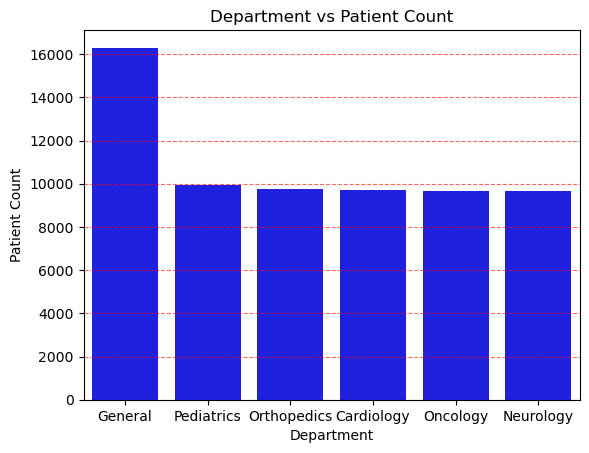

Departments with higher patient count may face operational overload and longer wait times.


In [162]:
# Bar chart
sns.countplot(data=df, x="Department", order=df["Department"].value_counts().index,color="blue")
plt.title("Department vs Patient Count")
plt.xlabel("Department")
plt.ylabel("Patient Count")
plt.grid(axis="y", linestyle="--", alpha=0.6, color="red")
plt.show()

print("Departments with higher patient count may face operational overload and longer wait times.")


In [73]:
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])

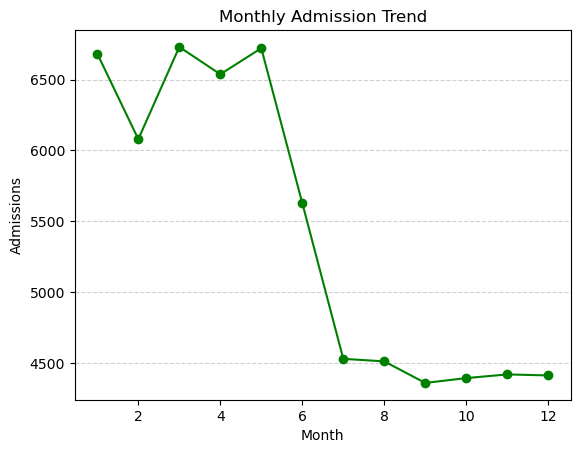

First 6 months have more admissions than the last 6 months of a year so hospitals need better planning for peak months


In [164]:
# Line chart

monthly = df.groupby(df["Admission_Date"].dt.month).size()
plt.plot(monthly.index, monthly.values, marker="o", color="green")
plt.title("Monthly Admission Trend")
plt.xlabel("Month")
plt.ylabel("Admissions")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()
print("First 6 months have more admissions than the last 6 months of a year so hospitals need better planning for peak months")

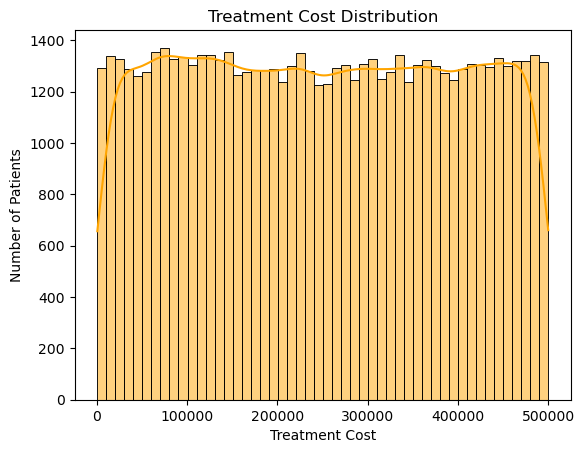

Most patients fall in a certain cost range while few patients have very high treatment cost.


In [141]:
# Histogram

sns.histplot(df["Treatment_Cost"], bins=50, kde=True, color="orange")
plt.title("Treatment Cost Distribution")
plt.xlabel("Treatment Cost")
plt.ylabel("Number of Patients")
plt.show()

print("Most patients fall in a certain cost range while few patients have very high treatment cost.")


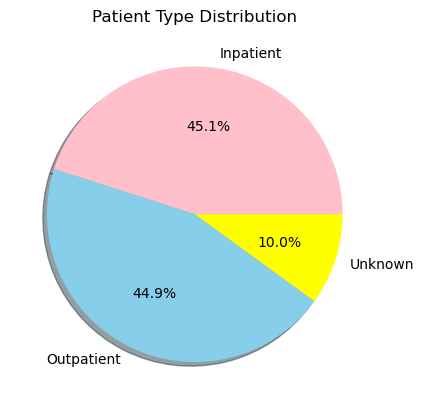

Shows the ratio between types of patients


In [150]:
# Pie chart

pt = df["Patient_Type"].value_counts()
colors=["pink","skyblue","yellow"]
plt.pie(pt, labels=pt.index, autopct="%1.1f%%", colors=colors, shadow=5)
plt.title("Patient Type Distribution")
plt.show()
print("Shows the ratio between types of patients")

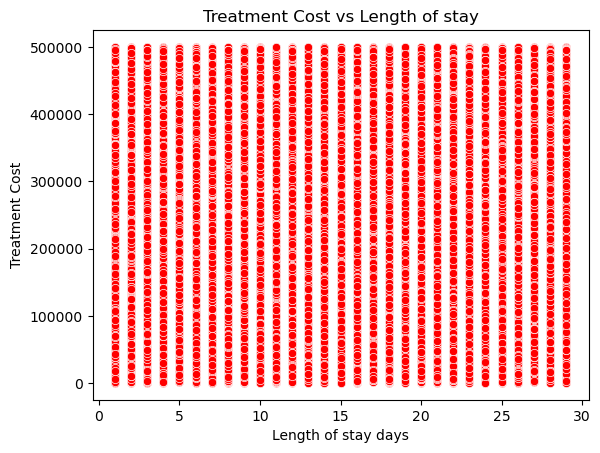

Shows the cost of treatment based on days the patient stayed


In [154]:
# Scatter Plot

sns.scatterplot(data=df, y="Treatment_Cost", x="Length_of_Stay_Days", color="Red")
plt.title("Treatment Cost vs Length of stay")
plt.ylabel("Treatment Cost")
plt.xlabel("Length of stay days")
plt.show()
print("Shows the cost of treatment based on days the patient stayed")

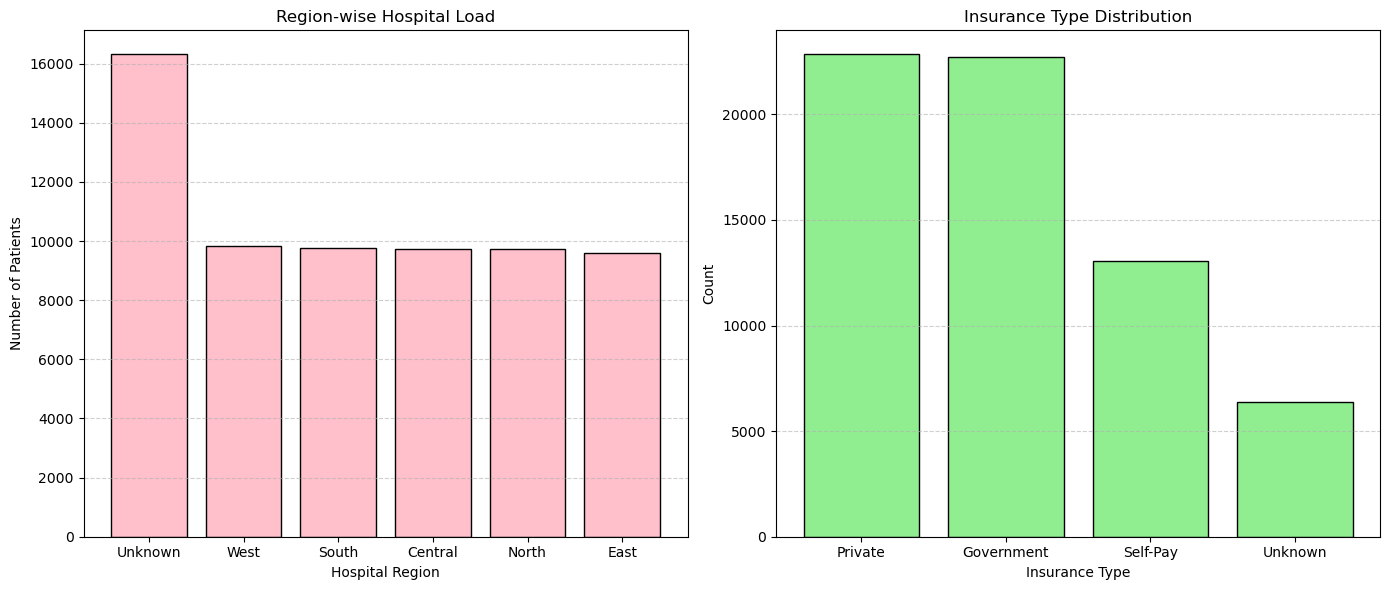

Regions with higher patient load need more resources and insurance type distribution shows the common payment methods used in hospitals.


In [160]:
# Subplots

# Subplot 1: Region-wise hospital load 
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
region_counts = df["Hospital_Region"].value_counts()
plt.bar(region_counts.index, region_counts.values, color="Pink", edgecolor="black")
plt.title("Region-wise Hospital Load")
plt.xlabel("Hospital Region")
plt.ylabel("Number of Patients")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Subplot 2: Insurance type distribution
plt.subplot(1,2,2)
insurance_counts = df["Insurance_Type"].value_counts()
plt.bar(insurance_counts.index, insurance_counts.values, color="lightgreen", edgecolor="black")
plt.title("Insurance Type Distribution")
plt.xlabel("Insurance Type")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("Regions with higher patient load need more resources and insurance type distribution shows the common payment methods used in hospitals.")


# **Task 5: Final Insights & Task Completion**

### Key Findings
- Some hospital regions have higher patient admissions.
- Certain departments receive more patients indicating higher demand for specific treatments.
- Treatment cost varies among patients showing both low-cost and high-cost cases.
- Inpatients generally have longer length of stay compared to outpatients.
- Treatment cost increases when length of stay increases.
- Most commom type of Insurance are from Private and Government.
- First 6 months have more admissions than the last 6 months of a year.

### Healthcare Insights
- High patient load in specific regions may lead to longer waiting times and staff pressure.
- Departments with higher patient count may face operational overload and longer wait times.
- Hospitals need better planning for peak months.

### Hospital improvements
- Add more staff in high-load departments.
- Improve discharge process to reduce stay duration.
- Plan resources based on monthly admission trends.
- Improve insurance processing for smoother billing.
